<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/feature%2Fhani-naive-bayes-model/DMW_GA_(Hani)_Naive_Bayes_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A: Naive Bayes Model & Metrics

Data Loaded. Training on 872 rows, Testing on 219 rows.

🤖 Training Gaussian Naive Bayes...

--- MODEL METRICS ---
Accuracy:  80.82%
Recall:    68.82%
F1 Score:  0.7529
ROC-AUC:   0.8649

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.84       126
           1       0.83      0.69      0.75        93

    accuracy                           0.81       219
   macro avg       0.81      0.79      0.80       219
weighted avg       0.81      0.81      0.80       219


🔍 Calculating Feature Importance (Permutation Method)...

Top 5 Features:
- Risk_Flag: 0.1607
- DTI_Ratio: 0.1009
- Loan_Term_Months: 0.0183
- Loan_Amount: 0.0169
- Has_Asset: 0.0110



/tmp/ipython-input-2589370110.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_5, palette='viridis')


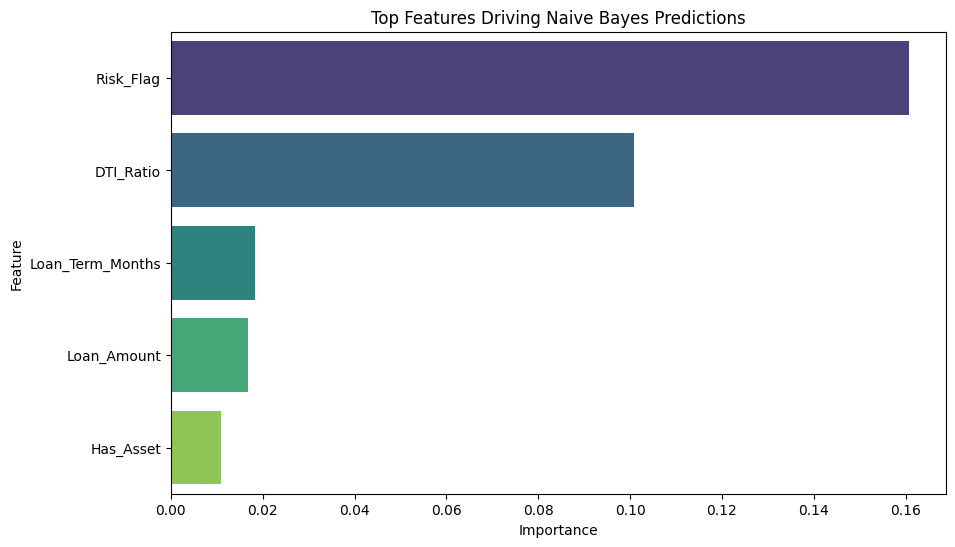

In [ ]:
# ==========================================
# STEP 1: Load and Preprocess Data
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score
)

# 1. Load Data
df = pd.read_csv('synthetic_data_cleaned_feature_engineered.csv', sep='|')

# 2. Define Features (X) and Target (y)
# Drop ID and Note (Text is already engineered into 'Risk_Flag')
X = df.drop(columns=['Customer_ID', 'Loan_Officer_Note', 'Default_Status'])
y = df['Default_Status']

# 3. Handle Categorical Data ('Occupation')
# Naive Bayes requires numerical input, so we use One-Hot Encoding
X = pd.get_dummies(X, columns=['Occupation'], drop_first=True)

# 4. Scale the Data (CRITICAL for Naive Bayes)
# GaussianNB assumes normal distribution, scaling helps it perform better
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 5. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Loaded. Training on {len(X_train)} rows, Testing on {len(X_test)} rows.")

# ==========================================
# STEP 2: Train Naive Bayes Model
# ==========================================
print("\n🤖 Training Gaussian Naive Bayes...")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC

# ==========================================
# STEP 3: Evaluate Performance
# ==========================================
# Calculate Metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred)
metric_f1 = f1_score(y_test, y_pred)
metric_auc = roc_auc_score(y_test, y_prob)

print("\n--- MODEL METRICS ---")
print(f"Accuracy:  {metric_accuracy:.2%}")
print(f"Recall:    {metric_recall:.2%}")
print(f"F1 Score:  {metric_f1:.4f}")
print(f"ROC-AUC:   {metric_auc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==========================================
# STEP 4: Calculate Feature Importance
# ==========================================
# Naive Bayes doesn't give feature importance directly, so we use Permutation Importance
print("\n🔍 Calculating Feature Importance (Permutation Method)...")
perms = permutation_importance(nb_model, X_test, y_test, n_repeats=10, random_state=42)

# Create a DataFrame for visualization
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perms.importances_mean
}).sort_values(by='Importance', ascending=False)

# Format top 5 features for the LLM prompt
top_5 = feature_importance.head(5)
top_features_str = ""
for index, row in top_5.iterrows():
    top_features_str += f"- {row['Feature']}: {row['Importance']:.4f}\n"

print("\nTop 5 Features:\n" + top_features_str)

# Optional: Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_5, palette='viridis')
plt.title('Top Features Driving Naive Bayes Predictions')
plt.show()

## STEP 1: SETUP & DATA PREPROCESSING
- handles all the data preparation.
- It cleans the columns, converts categories to numbers, and scales the data

In [ ]:
# ==========================================
# STEP 1: Imports & Data Preprocessing
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score
)

# 1. Load Data
# We use the dataset where we already fixed the text features
df = pd.read_csv('synthetic_data_cleaned_feature_engineered.csv', sep='|')

# 2. Define Features (X) and Target (y)
# We drop 'Loan_Officer_Note' because we already extracted 'Risk_Flag' from it.
# We drop 'Customer_ID' because it is just a random label.
X = df.drop(columns=['Customer_ID', 'Loan_Officer_Note', 'Default_Status'])
y = df['Default_Status']

# 3. Handle Categorical Data ('Occupation')
# Naive Bayes handles numbers, not words. We use "One-Hot Encoding"
# to turn 'Occupation' into columns like 'Occupation_Teacher', 'Occupation_Tech', etc.
X = pd.get_dummies(X, columns=['Occupation'], drop_first=True)

# 4. Scale the Data (CRITICAL for Naive Bayes)
# Gaussian Naive Bayes assumes data follows a normal "bell curve".
# Scaling ensures features like Income ($50,000) and Age (30) don't confuse the model due to size differences.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 5. Split Data (80% Train, 20% Test)
# stratify=y ensures we have the same percentage of defaulters in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Data Processed. Training on {len(X_train)} rows, Testing on {len(X_test)} rows.")

✅ Data Processed. Training on 872 rows, Testing on 219 rows.


## STEP 2: MODEL TRAINING
- Initializes the Gaussian Naive Bayes algorithm
- Teaches model using the training data

In [ ]:
# ==========================================
# STEP 2: Train Naive Bayes Model
# ==========================================
print("🤖 Training Gaussian Naive Bayes...")

# Initialize the model
nb_model = GaussianNB()

# Fit the model (The learning phase)
nb_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:, 1]  # Get probabilities for ROC-AUC calculation

print("✅ Model Trained successfully!")

🤖 Training Gaussian Naive Bayes...
✅ Model Trained successfully!


## STEP 3: EVALUATION METRICS

In [ ]:
# ==========================================
# STEP 3: Evaluate Performance
# ==========================================
# Calculate core metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred) # Crucial: Did we catch the bad guys?
metric_f1 = f1_score(y_test, y_pred)         # Balance between Precision and Recall
metric_auc = roc_auc_score(y_test, y_prob)   # Overall distinguishing power

print("\n--- MODEL METRICS ---")
print(f"Accuracy:  {metric_accuracy:.2%}")
print(f"Recall:    {metric_recall:.2%} (The ability to find actual defaulters)")
print(f"F1 Score:  {metric_f1:.4f}")
print(f"ROC-AUC:   {metric_auc:.4f}")

print("\n--- DETAILED REPORT ---")
print(classification_report(y_test, y_pred))


--- MODEL METRICS ---
Accuracy:  80.82%
Recall:    68.82% (The ability to find actual defaulters)
F1 Score:  0.7529
ROC-AUC:   0.8649

--- DETAILED REPORT ---
              precision    recall  f1-score   support

           0       0.80      0.90      0.84       126
           1       0.83      0.69      0.75        93

    accuracy                           0.81       219
   macro avg       0.81      0.79      0.80       219
weighted avg       0.81      0.81      0.80       219



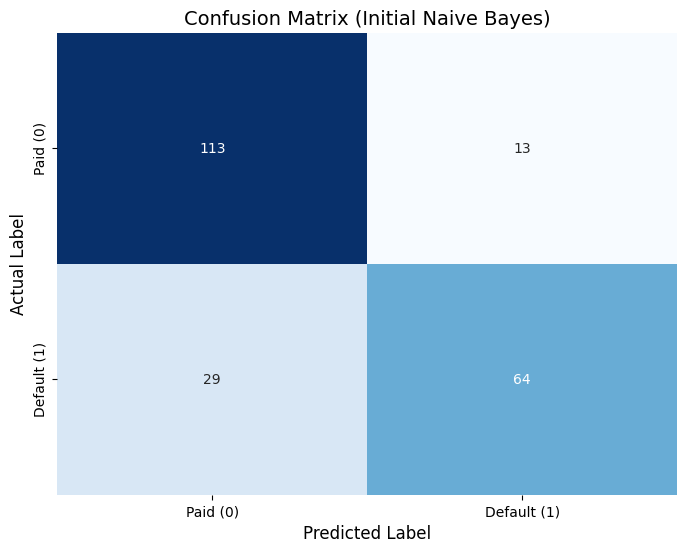


--- INITIAL MATRIX INTERPRETATION ---
✅ True Negatives (Correctly predicted 'Paid'): 113
❌ False Positives (Predicted 'Default' but paid): 13
⚠️ False Negatives (Predicted 'Paid' but defaulted): 29 (This is the critical error)
✅ True Positives (Correctly predicted 'Default'): 64


In [ ]:
# ==========================================
# STEP 3.5: Confusion Matrix (Before Tuning)
# ==========================================
# 1. Compute Matrix
cm_initial = confusion_matrix(y_test, y_pred)

# 2. Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_initial, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Paid (0)', 'Default (1)'],
            yticklabels=['Paid (0)', 'Default (1)'])

plt.title('Confusion Matrix (Initial Naive Bayes)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

# 3. Interpretation
tn, fp, fn, tp = cm_initial.ravel()
print("\n--- INITIAL MATRIX INTERPRETATION ---")
print(f"✅ True Negatives (Correctly predicted 'Paid'): {tn}")
print(f"❌ False Positives (Predicted 'Default' but paid): {fp}")
print(f"⚠️ False Negatives (Predicted 'Paid' but defaulted): {fn} (This is the critical error)")
print(f"✅ True Positives (Correctly predicted 'Default'): {tp}")

## STEP 4: FEATURE IMPORTANCE & VISUALIZATIONS
- Use a technique called "Permutation Importance" (shuffling data to see what breaks the model) to find out which features matter most

🔍 Calculating Feature Importance (Permutation Method)...

--- TOP 5 PREDICTIVE FEATURES ---
- Risk_Flag: 0.1607
- DTI_Ratio: 0.1009
- Loan_Term_Months: 0.0183
- Loan_Amount: 0.0169
- Has_Asset: 0.0110



/tmp/ipython-input-2763479080.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_5, palette='viridis')


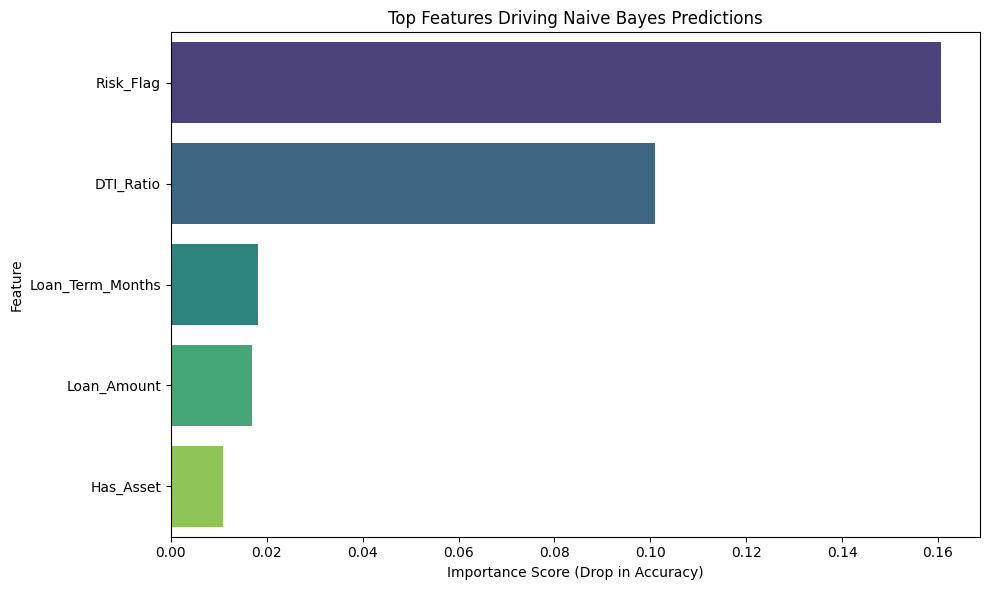

In [ ]:
# ==========================================
# STEP 4: Visualizing Feature Importance
# ==========================================
print("🔍 Calculating Feature Importance (Permutation Method)...")

# We shuffle each feature one by one to see how much the accuracy drops.
# If accuracy drops a lot, that feature was very important.
perms = permutation_importance(nb_model, X_test, y_test, n_repeats=10, random_state=42)

# Create a DataFrame to organize results
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perms.importances_mean
}).sort_values(by='Importance', ascending=False)

# Format top 5 features for the LLM prompt later
top_5 = feature_importance.head(5)
top_features_str = ""
for index, row in top_5.iterrows():
    top_features_str += f"- {row['Feature']}: {row['Importance']:.4f}\n"

print("\n--- TOP 5 PREDICTIVE FEATURES ---")
print(top_features_str)

# Plot the graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_5, palette='viridis')
plt.title('Top Features Driving Naive Bayes Predictions')
plt.xlabel('Importance Score (Drop in Accuracy)')
plt.tight_layout()
plt.show()

## 4.5 Hyperparameter Tuning
While Naive Bayes is a simple algorithm with very few "knobs" to turn, there is one key hyperparameter you can tune: var_smoothing.

What it does: It adds a tiny amount of noise to the data's variance. This helps stability and can sometimes help the model handle "weird" data points or skewed distributions better

In [ ]:
# ==========================================
# STEP 4.5: Hyperparameter Tuning (Grid Search)
# ==========================================
from sklearn.model_selection import GridSearchCV

print("🔧 Starting Hyperparameter Tuning for Naive Bayes...")

# 1. Define the Parameter Grid
# 'var_smoothing' is the main knob for Naive Bayes (handles data variances)
param_grid = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

# 2. Setup Grid Search
grid_search = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    cv=5,
    scoring='recall',  # Optimizing for Recall (catching defaulters)
    verbose=1,
    n_jobs=-1
)

# 3. Fit the Search
grid_search.fit(X_train, y_train)
best_nb_model = grid_search.best_estimator_

print(f"\n✅ Tuning Complete! Best var_smoothing: {grid_search.best_params_['var_smoothing']:.9f}")

# 4. Evaluate Tuned Model
y_pred_tuned = best_nb_model.predict(X_test)
y_prob_tuned = best_nb_model.predict_proba(X_test)[:, 1] # Needed for ROC-AUC

# Calculate New Metrics
tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

# 5. Print formatted results
print("\n--- MODEL METRICS ---")
print(f"Accuracy:  {tuned_acc:.2%}")
print(f"Recall:    {tuned_recall:.2%} (The ability to find actual defaulters)")
print(f"F1 Score:  {tuned_f1:.4f}")
print(f"ROC-AUC:   {tuned_auc:.4f}")

print("\n--- DETAILED REPORT ---")
print(classification_report(y_test, y_pred_tuned))

# 6. Comparison Table (Before vs After)
print("\n" + "="*55)
print("📊 TUNING IMPACT ANALYSIS (Before vs After)")
print("="*55)
print(f"{'Metric':<15} | {'Before':<10} | {'After':<10} | {'Change':<10}")
print("-" * 55)
print(f"{'Accuracy':<15} | {metric_accuracy:.2%}     | {tuned_acc:.2%}     | {tuned_acc - metric_accuracy:+.2%}")
print(f"{'Recall':<15} | {metric_recall:.2%}     | {tuned_recall:.2%}     | {tuned_recall - metric_recall:+.2%}")
print(f"{'F1 Score':<15} | {metric_f1:.4f}     | {tuned_f1:.4f}     | {tuned_f1 - metric_f1:+.4f}")
print(f"{'ROC-AUC':<15} | {metric_auc:.4f}     | {tuned_auc:.4f}     | {tuned_auc - metric_auc:+.4f}")
print("="*55)

# Update variables for the LLM step (Optional - if you want LLM to analyze the NEW model)
# metric_accuracy = tuned_acc
# metric_recall = tuned_recall
# metric_f1 = tuned_f1
# metric_auc = tuned_auc

🔧 Starting Hyperparameter Tuning for Naive Bayes...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

✅ Tuning Complete! Best var_smoothing: 0.018738174

--- MODEL METRICS ---
Accuracy:  80.82%
Recall:    68.82% (The ability to find actual defaulters)
F1 Score:  0.7529
ROC-AUC:   0.8601

--- DETAILED REPORT ---
              precision    recall  f1-score   support

           0       0.80      0.90      0.84       126
           1       0.83      0.69      0.75        93

    accuracy                           0.81       219
   macro avg       0.81      0.79      0.80       219
weighted avg       0.81      0.81      0.80       219


📊 TUNING IMPACT ANALYSIS (Before vs After)
Metric          | Before     | After      | Change    
-------------------------------------------------------
Accuracy        | 80.82%     | 80.82%     | +0.00%
Recall          | 68.82%     | 68.82%     | +0.00%
F1 Score        | 0.7529     | 0.7529     | +0.0000
ROC-AUC         | 0.8649     | 0.8601

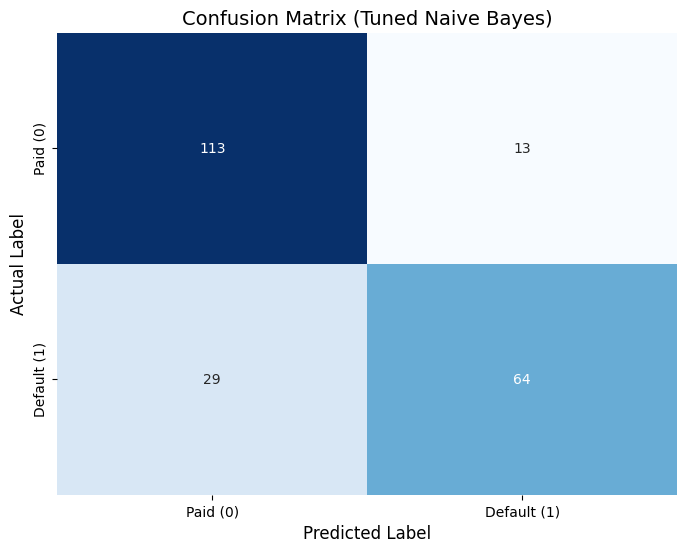


--- MATRIX INTERPRETATION ---
✅ True Negatives (Correctly predicted 'Paid'): 113
❌ False Positives (Predicted 'Default' but paid): 13 (Lost Business)
⚠️ False Negatives (Predicted 'Paid' but defaulted): 29 (Dangerous Risk!)
✅ True Positives (Correctly predicted 'Default'): 64


In [ ]:
# ==========================================
# STEP 4.6: Visualizing the Confusion Matrix
# ==========================================
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Compute Matrix
cm = confusion_matrix(y_test, y_pred_tuned)

# 2. Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Paid (0)', 'Default (1)'],
            yticklabels=['Paid (0)', 'Default (1)'])

plt.title('Confusion Matrix (Tuned Naive Bayes)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

# 3. Interpretation Printout
tn, fp, fn, tp = cm.ravel()
print("\n--- MATRIX INTERPRETATION ---")
print(f"✅ True Negatives (Correctly predicted 'Paid'): {tn}")
print(f"❌ False Positives (Predicted 'Default' but paid): {fp} (Lost Business)")
print(f"⚠️ False Negatives (Predicted 'Paid' but defaulted): {fn} (Dangerous Risk!)")
print(f"✅ True Positives (Correctly predicted 'Default'): {tp}")

# Part B: The LLM Analysis (The Insight)
Use LLMs to summarise findings, provide insights, and interpret feature importance.

In [ ]:
# ==========================================
# STEP 5: Automated LLM Analysis (Mistral-7B)
# ==========================================
# 1. Install Libraries (Run once, then RESTART RUNTIME if you haven't yet)
!pip install -U bitsandbytes accelerate

import torch
import gc
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from huggingface_hub import login
from google.colab import userdata

# --- 0. CRITICAL: ANTI-CRASH MEMORY CLEANING ---
# This wipes the GPU memory clean before loading the new model
if 'model' in locals():
    del model
if 'generator' in locals():
    del generator
gc.collect()
torch.cuda.empty_cache()
print("🧹 GPU Memory Cleared. Ready to load.")

# --- 1. CONFIGURATION ---
# Mistral-7B-Instruct-v0.3 (High performance, fits in Colab 4-bit)
model_name = "mistralai/Mistral-7B-Instruct-v0.3"

# --- 1. CONFIGURATION ---
# PASTE YOUR TOKEN BELOW
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

# --- 2. SETUP MODEL ---
print(f"⏳ Loading {model_name}...")

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

try:
    tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quant_config,
        device_map="auto",
        token= hf_token
    )

    generator = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=1000,
        pad_token_id=tokenizer.eos_token_id
    )
    print("✅ Mistral-7B Loaded Successfully!")

except Exception as e:
    print(f"❌ Error: {e}")
    print("Tip: If it says 'Out of Memory', go to 'Runtime' -> 'Disconnect and Delete Runtime', then Run All again.")

# --- 3. CONSTRUCT PROMPT ---
messages = [
    {
        "role": "system",
        "content": "You are a Senior Data Scientist. Write a structured performance report."
    },
    {
        "role": "user",
        "content": f"""
        I have trained a Naive Bayes model to predict Loan Defaults.
        Generate a detailed insight report based on these metrics:

        ### MODEL METRICS:
        - Accuracy: {metric_accuracy:.2%}
        - Recall: {metric_recall:.2%} (Ability to catch defaulters)
        - F1-Score: {metric_f1:.4f}
        - ROC-AUC: {metric_auc:.4f}

        ### TOP IMPORTANT FEATURES:
        {top_features_str}

        ### INSTRUCTIONS:
        Please generate the response EXACTLY in this format:

        1. Summarize the model's performance. Is it good for risk management?
        [Analyze accuracy/recall. Explain implications for the bank.]

        2. Interpret the Feature Importance. Why are these specific features predictive?
        [Bulleted list. Explain business logic for each feature.]

        3. Provide one business recommendation.
        [Suggest next steps like switching models.]
        """
    }
]

# Apply Chat Template
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# --- 4. GENERATE REPORT ---
if 'generator' in locals():
    print("\n🤖 Generating Report with Mistral...")
    output = generator(
        prompt,
        do_sample=True,
        temperature=0.3,
        top_p=0.9
    )

    # Extract response
    response = output[0]['generated_text']
    # Mistral v0.3 often uses [INST] or specific tokens, but usually splits well here:
    print("\n" + "="*50)
    print("📝 MISTRAL AUTOMATED INSIGHTS")
    print("="*50)
    print(response.split(prompt)[-1].strip())

🧹 GPU Memory Cleared. Ready to load.
⏳ Loading mistralai/Mistral-7B-Instruct-v0.3...


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

KeyboardInterrupt: 

# Git

In [ ]:
# ==========================================
# 🚀 AUTOMATED GITHUB PUSH (Branch Edition)
# ==========================================
import os

# --- 1. CONFIGURATION (Change these!) ---
USER_NAME = "hanidew"
USER_EMAIL = "hanijasmina@gmail.com"
TOKEN = "GIT_TOKEN"  # Paste your Token here
REPO_NAME = "WIE3007-DMW-GroupProject"
FILE_NAME = "DMW_GA (Hani) - Naive Bayes Model.ipynb"
COMMIT_MESSAGE = "Updated git command code"

# 🔴 NEW CHANGE: Define your branch name here
BRANCH_NAME = "feature/hani-naive-bayes-model"

# --- 2. THE MAGIC SCRIPT ---
# Clone the repo silently
repo_url = f"https://{TOKEN}@github.com/{USER_NAME}/{REPO_NAME}.git"

!git config --global user.email "{USER_EMAIL}"
!git config --global user.name "{USER_NAME}"

# Remove existing repo dir if it exists to avoid conflicts
if os.path.exists(REPO_NAME):
    !rm -rf {REPO_NAME}

# Clone
!git clone {repo_url}

# Move into the directory
%cd {REPO_NAME}

# 🔴 NEW CHANGE: Create and switch to the new branch
!git checkout -b {BRANCH_NAME}

# Copy the current notebook into the repo folder
# (We need to copy it AFTER moving into the directory or use full paths.
#  The previous script copied it *before* cd-ing, but to be safe with branches
#  let's use the parent directory path '..' to find the file)
!cp "../{FILE_NAME}" .

# Add, Commit
!git add .
!git commit -m "{COMMIT_MESSAGE}"

# 🔴 NEW CHANGE: Push to the specific branch
!git push origin {BRANCH_NAME}

# Move back
%cd ..
print(f"\n✅ SUCCESS! File pushed to branch '{BRANCH_NAME}' at https://github.com/{USER_NAME}/{REPO_NAME}/tree/{BRANCH_NAME}")